In [ ]:
import numpy as np
import pandas as pd
import os

# Load local datasets
train_df = pd.read_csv('maritime_train.csv')
test_df = pd.read_csv('maritime_test.csv')


**Insight:** We set up our Python environment by importing core libraries (pandas, numpy, os) and loaded the training and test datasets from local CSV files for preprocessing and analysis.

In [3]:
display(train_df.head())

,PassengerId,TicketTier,PassengerName,Gender,Age,RelativesAboard,ParentsChildren,CLass,TicketCost,Berth,BoardingPort,FamilySize,Singleton,FarePerPerson,Title,Outcome
0,338.376107,0.977533,"Partner, Mr. Austen",male,NaN,0.005991,-0.024062,113043,29.104891,C124,S,1,1,25.906873,Mr,0
1,732.225160,2.016456,"Berriman, Mr. William John",male,21.574386,0.091114,-0.021340,28425,11.033567,NaN,S,1,1,10.939094,Mr,0
2,391.314100,2.998448,"Tikkanen, Mr. Juho",male,33.490756,-0.072885,-0.021702,STON/O 2. 3101293,2.234540,NaN,S,1,1,4.065968,Mr,0
3,724.550481,3.045488,"Hansen, Mr. Henrik Juul",male,25.200171,0.913680,0.032986,350025,10.958320,NaN,S,2,0,3.733784,Mr,0
4,810.994274,3.004710,"Andersson, Miss. Ebba Iris Alfrida",female,5.839590,4.009691,1.956266,347082,33.765343,NaN,S,7,0,3.325612,Miss,0


**Insight:** A quick inspection of the head of the training data shows columns like `PassengerId`, `TicketTier`, `PassengerName`, `Gender`, `Age`, `RelativesAboard`, `ParentsChildren`, `CLass`, and `TicketCost`. We see some missing values (`NaN`) in the `Age` column, indicating a need for data cleaning.

# Exploratory Data Analysis (EDA)

In [4]:
print('for train set is:',train_df.shape)
print('for test set is:', test_df.shape)

for train set is: (712, 16)
for test set is: (179, 15)


**Insight:** The training set consists of 712 rows and 16 columns (including the target variable `Outcome`), while the test set has 179 rows and 15 columns (excluding the target).

In [5]:
print("Missing values in Training Data:")
display(train_df.isnull().sum())

print("\nMissing values in Test Data:")
display(test_df.isnull().sum())

# we will do the descriptive Statistics
print("\nDescriptive Statistics (Training Data):")
display(train_df.describe())

Missing values in Training Data:


PassengerId          0
TicketTier           0
PassengerName        0
Gender               0
Age                197
RelativesAboard      0
ParentsChildren      0
CLass                0
TicketCost           0
Berth              553
BoardingPort         2
FamilySize           0
Singleton            0
FarePerPerson        0
Title                0
Outcome              0
dtype: int64


Missing values in Test Data:


PassengerId          0
TicketTier           0
PassengerName        0
Gender               0
Age                 49
RelativesAboard      0
ParentsChildren      0
CLass                0
TicketCost           0
Berth              134
BoardingPort         0
FamilySize           0
Singleton            0
FarePerPerson        0
Title                0
dtype: int64


Descriptive Statistics (Training Data):


,PassengerId,TicketTier,Age,RelativesAboard,ParentsChildren,TicketCost,FamilySize,Singleton,FarePerPerson,Outcome
count,712.000000,712.000000,515.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,448.089668,2.333755,29.783025,0.555223,0.378523,32.456248,1.932584,0.602528,20.043894,0.376404
std,256.347351,0.826466,14.605177,1.174990,0.791899,52.079443,1.682525,0.489719,38.109959,0.484824
min,-19.969283,0.893173,-1.128370,-0.148789,-0.115958,-3.982686,1.000000,0.000000,-4.526815,0.000000
25%,222.160559,1.954529,20.666161,-0.016907,-0.020213,8.380745,1.000000,0.000000,6.596378,0.000000
50%,455.043258,2.954504,28.374231,0.040156,0.017184,14.833240,1.000000,1.000000,9.272521,0.000000
75%,671.639433,3.006993,38.707210,0.967004,0.082670,30.775352,2.000000,1.000000,18.980591,1.000000
max,905.400989,3.108531,79.849115,8.027245,6.045675,514.074158,11.000000,1.000000,512.004226,1.000000


**Insight:** We find missing values in `Age` (197 train, 49 test), `Berth` (553 train, 134 test), and `BoardingPort` (2 train). `Berth` is missing in over 75% of cases and may need to be dropped. Descriptive statistics also show that some `Age` values are negative (e.g., min of -1.12), which indicates data noise, and the average survival rate (`Outcome` mean) is approximately 37.6%.

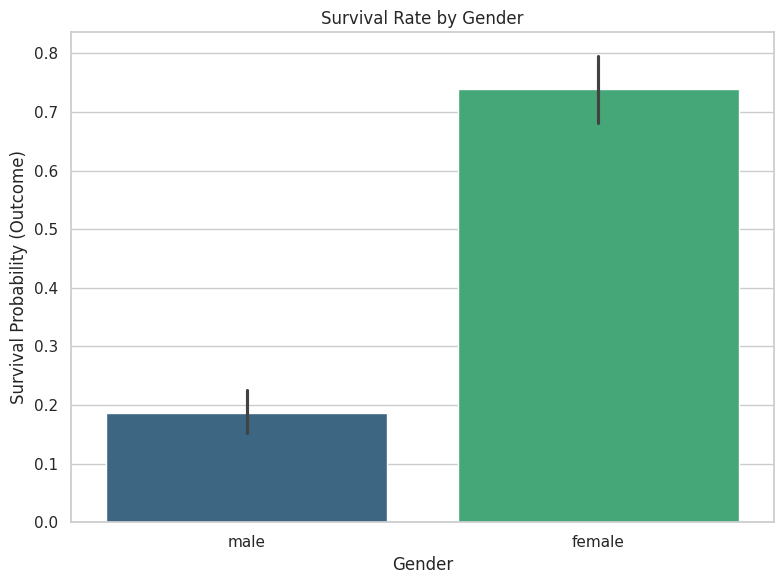

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


fig, ax = plt.subplots(figsize=(8, 6))

# Survival Rate (Outcome) by Gender plotting: 
sns.barplot(data=train_df, x='Gender', y='Outcome', ax=ax, palette='viridis', hue='Gender', legend=False)
ax.set_title('Survival Rate by Gender')
ax.set_ylabel('Survival Probability (Outcome)')

plt.tight_layout()
plt.show()

**Insight:** The barplot illustrates a significant difference in survival rates between genders, indicating that female passengers had a much higher probability of survival than male passengers.

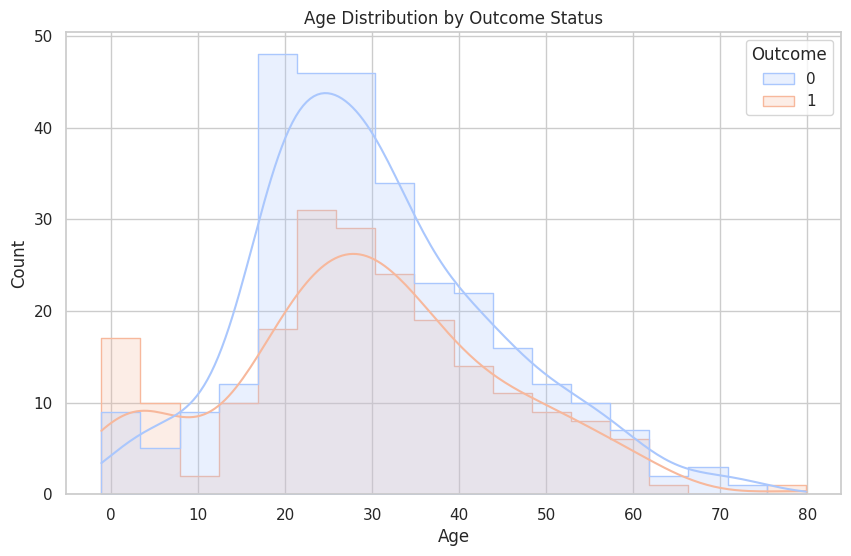

In [7]:
 # Age Distribution by Outcome
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='Age', hue='Outcome', kde=True, element='step', palette='coolwarm')
plt.title('Age Distribution by Outcome Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Insight:** The age distribution shows a high density of passengers between ages 20 and 40. We observe that younger passengers (especially children) have a higher ratio of survival, whereas the survival rate decreases for older age groups.

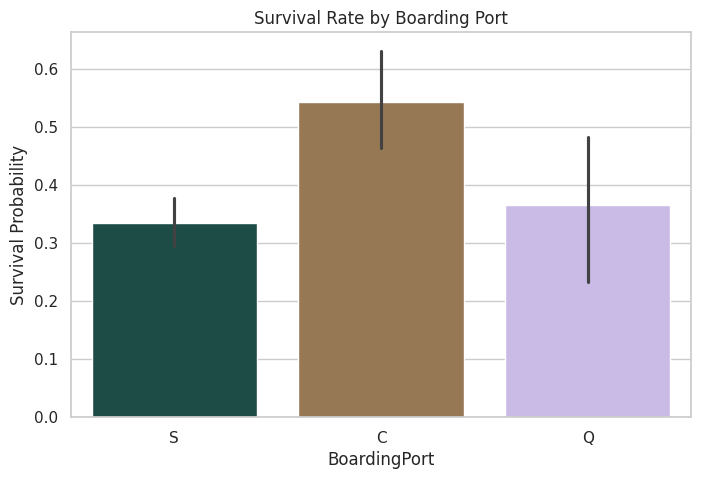

In [8]:
# Survival Rate by Boarding Port
plt.figure(figsize=(8, 5))
sns.barplot(data=train_df, x='BoardingPort', y='Outcome', palette='cubehelix', hue='BoardingPort', legend=False)
plt.title('Survival Rate by Boarding Port')
plt.ylabel('Survival Probability')
plt.show()

**Insight:** Survival rates vary across different boarding ports, suggesting that the port of embarkation might correlate with socioeconomic status or ticket tier, influencing survival probability.

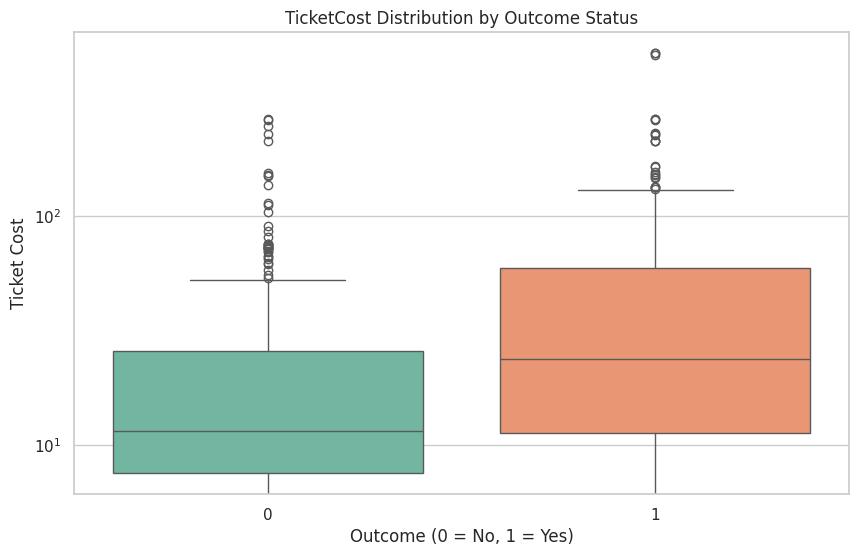

In [9]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_df,
    x='Outcome',
    y='TicketCost',
    hue='Outcome',
    palette='Set2',
    legend=False
)

plt.title('TicketCost Distribution by Outcome Status')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Ticket Cost')
plt.yscale('log')
plt.show()

**Insight:** Passengers who survived (`Outcome = 1`) generally had higher ticket costs, as shown by the shifted boxplot. This indicates a positive correlation between socioeconomic status/wealth and survival probability.

In [10]:
print(f"The target variable is: Outcome")
print("Unique values in 'Outcome':", train_df['Outcome'].unique())
print("\nValue counts:")
display(train_df['Outcome'].value_counts())

The target variable is: Outcome
Unique values in 'Outcome': [0 1]

Value counts:


Outcome
0    444
1    268
Name: count, dtype: int64

**Insight:** The target variable `Outcome` is binary (0 or 1). The dataset is somewhat imbalanced, with 444 non-survivors (62.4%) and 268 survivors (37.6%) in the training set.

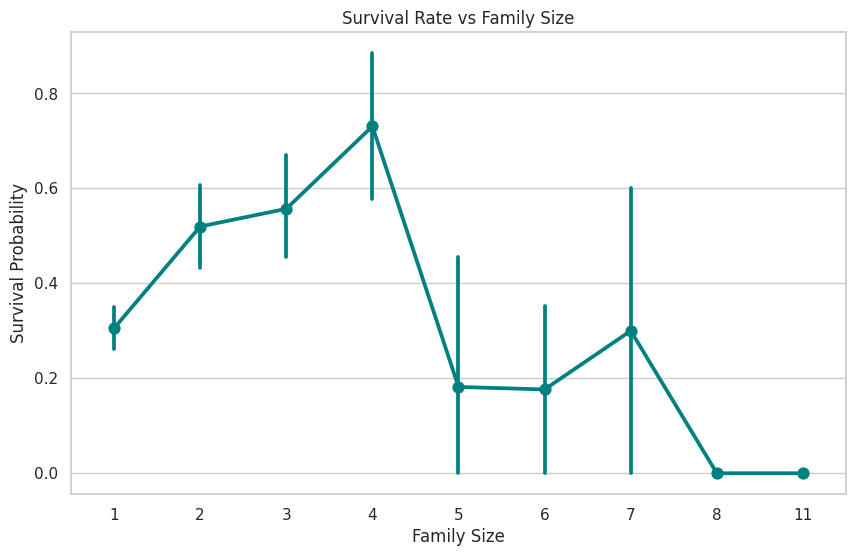

In [11]:
# Survival Rate by FamilySize
plt.figure(figsize=(10, 6))
sns.pointplot(data=train_df, x='FamilySize', y='Outcome', color='teal')
plt.title('Survival Rate vs Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Probability')
plt.show()

**Insight:** Survival probability peaks for family sizes between 2 and 4, whereas single passengers or those with very large family sizes (e.g., > 5) show lower survival rates.

### Data Cleaning: Handling Missing Values

In [12]:
# Handle Missing Age by  median
train_df['Age'] = train_df['Age'].fillna(train_df.groupby('Title')['Age'].transform('median'))
test_df['Age'] = test_df['Age'].fillna(test_df.groupby('Title')['Age'].transform('median'))


port_mode = train_df['BoardingPort'].mode()[0]
train_df['BoardingPort'] = train_df['BoardingPort'].fillna(port_mode)
test_df['BoardingPort'] = test_df['BoardingPort'].fillna(port_mode)

train_df.drop(columns=['Berth'], inplace=True, errors='ignore')
test_df.drop(columns=['Berth'], inplace=True, errors='ignore')

print("Remaining missing values in Training Data:")
print(train_df.isnull().sum())

print("\nRemaining missing values in Test Data:")
print(test_df.isnull().sum())

Remaining missing values in Training Data:
PassengerId        0
TicketTier         0
PassengerName      0
Gender             0
Age                0
RelativesAboard    0
ParentsChildren    0
CLass              0
TicketCost         0
BoardingPort       0
FamilySize         0
Singleton          0
FarePerPerson      0
Title              0
Outcome            0
dtype: int64

Remaining missing values in Test Data:
PassengerId        0
TicketTier         0
PassengerName      0
Gender             0
Age                0
RelativesAboard    0
ParentsChildren    0
CLass              0
TicketCost         0
BoardingPort       0
FamilySize         0
Singleton          0
FarePerPerson      0
Title              0
dtype: int64


**Insight:** Missing `Age` values were imputed using the median age for each passenger's `Title`. Missing `BoardingPort` values were filled with the mode, and the highly-sparse `Berth` column was dropped, resulting in zero remaining missing values in both sets.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder


features_to_drop = ['PassengerId', 'PassengerName', 'Outcome']
X = train_df.drop(columns=features_to_drop, errors='ignore')
y = train_df['Outcome']

#  Apply Ordinal Encoding to 'TicketTier' and 'CLass'
# These columns contain mixed types or strings that need numerical representation
ord_cols = ['TicketTier', 'CLass']
ord_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[ord_cols] = ord_encoder.fit_transform(X[ord_cols].astype(str))

# Encode remaining categorical columns (Gender, BoardingPort, Title)
le = LabelEncoder()
for col in ['Gender', 'BoardingPort', 'Title']:
    if col in X.columns:
        X[col] = le.fit_transform(X[col].astype(str))

# Split into Training and Validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Preprocessing complete. Training set shape: {X_train.shape}")
display(X_train.head())

Preprocessing complete. Training set shape: (569, 12)


,TicketTier,Gender,Age,RelativesAboard,ParentsChildren,CLass,TicketCost,BoardingPort,FamilySize,Singleton,FarePerPerson,Title
375,546.0,1,29.591412,0.032190,0.027519,389.0,25.159020,1,1,1,24.084053,2
344,495.0,0,21.732031,7.964363,2.090316,470.0,73.745965,2,11,0,8.510164,1
526,266.0,0,31.714546,1.035129,1.933395,464.0,29.983611,2,4,0,3.023957,3
24,549.0,0,63.897759,-0.065376,-0.082612,406.0,9.772651,2,1,1,7.573638,3
234,163.0,0,13.270254,0.990830,-0.077863,109.0,30.091276,0,2,0,16.353314,3


**Insight:** Categorical features like `TicketTier` and `CLass` were ordinal-encoded, while `Gender`, `BoardingPort`, and `Title` were label-encoded. The preprocessed training set contains 569 samples with 12 features, split from the original training data.

### Feature Engineering with PCA

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

# Prepare copies
train_pca_df = train_df.copy()
test_pca_df = test_df.copy()


le = LabelEncoder()
cat_cols = ['Gender', 'BoardingPort', 'Title']
for col in cat_cols:
    train_pca_df[col] = le.fit_transform(train_pca_df[col].astype(str))
    test_pca_df[col] = le.transform(test_pca_df[col].astype(str))

# PCA
X = train_pca_df.select_dtypes(include=[np.number]).drop(columns=['Outcome', 'PassengerId'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

train_pca_df['PCA1'] = pca_result[:, 0]
train_pca_df['PCA2'] = pca_result[:, 1]

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2f}")

Explained variance ratio: [0.30287504 0.22622162]
Total variance explained: 0.53


**Insight:** Standardizing features followed by 2-component PCA shows that the first two components explain 53% of the total variance (30.3% and 22.6% respectively).

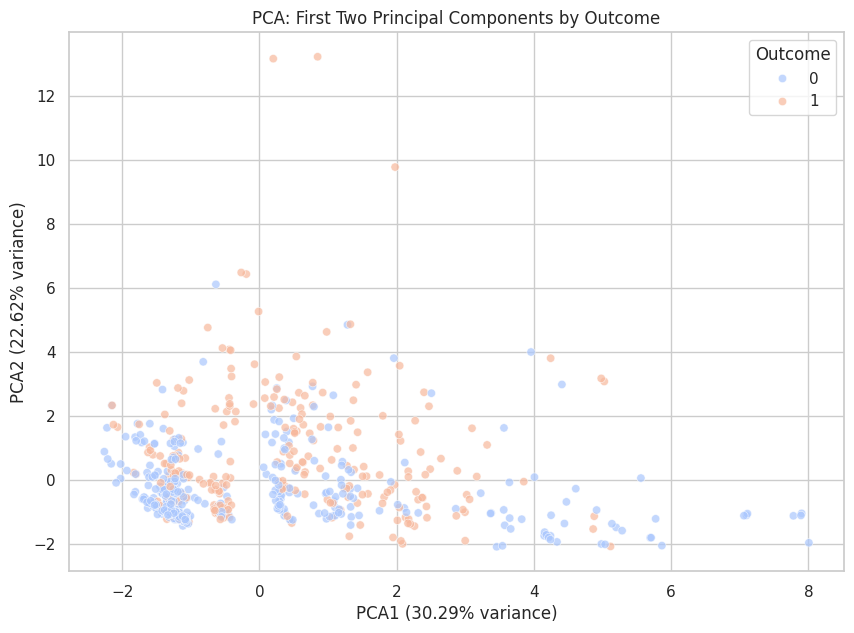

In [15]:
# Visualize PCA Components
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Outcome', data=train_pca_df, palette='coolwarm', alpha=0.7)
plt.title('PCA: First Two Principal Components by Outcome')
plt.xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Outcome', loc='best')
plt.show()

**Insight:** The PCA scatterplot shows some overlapping but distinct clusters for survivors versus non-survivors, suggesting that the lower-dimensional space retains class-distinguishing signals.

# Model Selection / Training

### Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler


results = {}


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_val_scaled)

# Evaluate
acc_lr = accuracy_score(y_val, y_pred_lr)

results['Logistic Regression'] = acc_lr

print(f"Accuracy: {acc_lr:.4f}")
print(classification_report(y_val, y_pred_lr))

Accuracy: 0.7972
              precision    recall  f1-score   support

           0       0.83      0.84      0.83        87
           1       0.75      0.73      0.74        56

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143



**Insight:** Logistic Regression achieves an accuracy of 79.72% on the validation set, with an f1-score of 0.83 for non-survivors (0) and 0.74 for survivors (1).

### Random Forest Classifier

In [17]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
results['Random Forest'] = acc_rf

print(f"--- Random Forest ---")
print(f"Accuracy: {acc_rf:.4f}")
print(classification_report(y_val, y_pred_rf))

--- Random Forest ---
Accuracy: 0.8252
              precision    recall  f1-score   support

           0       0.84      0.87      0.86        87
           1       0.79      0.75      0.77        56

    accuracy                           0.83       143
   macro avg       0.82      0.81      0.81       143
weighted avg       0.82      0.83      0.82       143



**Insight:** The Random Forest Classifier improves validation accuracy to 82.52%, showing stronger precision and recall performance for both classes compared to Logistic Regression.

### Gradient Boosting

In [18]:
from sklearn.ensemble import GradientBoostingClassifier


gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_val)
acc_gb = accuracy_score(y_val, y_pred_gb)
results['Gradient Boosting'] = acc_gb

print(f"--- Gradient Boosting ---")
print(f"Accuracy: {acc_gb:.4f}")
print(classification_report(y_val, y_pred_gb))

--- Gradient Boosting ---
Accuracy: 0.8182
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        87
           1       0.80      0.71      0.75        56

    accuracy                           0.82       143
   macro avg       0.81      0.80      0.81       143
weighted avg       0.82      0.82      0.82       143



**Insight:** Gradient Boosting performs competitively, achieving 81.82% validation accuracy with a particularly high recall (0.89) for the non-survivor class.

### XG Boost

In [19]:
from xgboost import XGBClassifier

# Initialize and train XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_val)
acc_xgb = accuracy_score(y_val, y_pred_xgb)
results['XGBoost'] = acc_xgb

print(f"--- XGBoost ---")
print(f"Accuracy: {acc_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb))

--- XGBoost ---
Accuracy: 0.8252
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        87
           1       0.80      0.73      0.77        56

    accuracy                           0.83       143
   macro avg       0.82      0.81      0.81       143
weighted avg       0.82      0.83      0.82       143



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:24:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Insight:** XGBoost achieves 82.52% accuracy, matching Random Forest's performance with a solid F1-score of 0.77 for survivors and 0.86 for non-survivors.

### Light GBM

In [20]:
from lightgbm import LGBMClassifier

# Initialize and train LightGBM
lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train)

# Evaluate
y_pred_lgbm = lgbm_model.predict(X_val)
acc_lgbm = accuracy_score(y_val, y_pred_lgbm)
results['LightGBM'] = acc_lgbm

print(f"--- LightGBM ---")
print(f"Accuracy: {acc_lgbm:.4f}")
print(classification_report(y_val, y_pred_lgbm))

--- LightGBM ---
Accuracy: 0.8392
              precision    recall  f1-score   support

           0       0.86      0.89      0.87        87
           1       0.81      0.77      0.79        56

    accuracy                           0.84       143
   macro avg       0.83      0.83      0.83       143
weighted avg       0.84      0.84      0.84       143



**Insight:** LightGBM yields the highest validation accuracy of 83.92% among all models, demonstrating robust classification capabilities with balanced precision and recall.

### Confusion Matrix

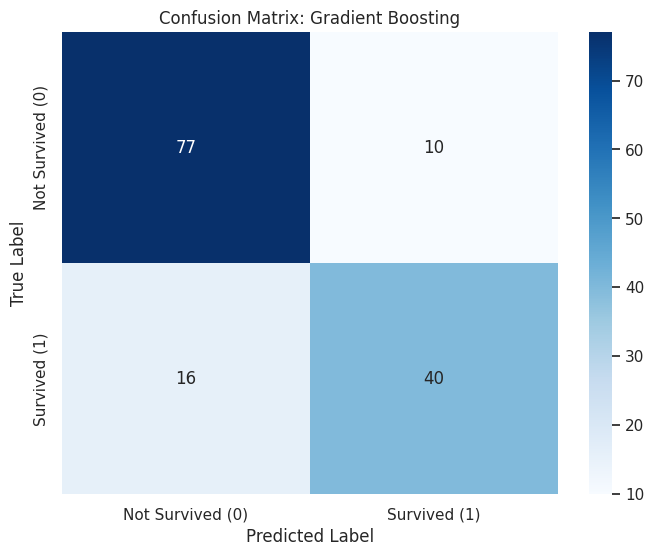

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_val, y_pred_gb)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived (0)', 'Survived (1)'],
            yticklabels=['Not Survived (0)', 'Survived (1)'])
plt.title('Confusion Matrix: Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Insight:** The confusion matrix for Gradient Boosting reveals 77 True Negatives, 40 True Positives, 10 False Positives, and 16 False Negatives, demonstrating strong predictive accuracy for both classes.

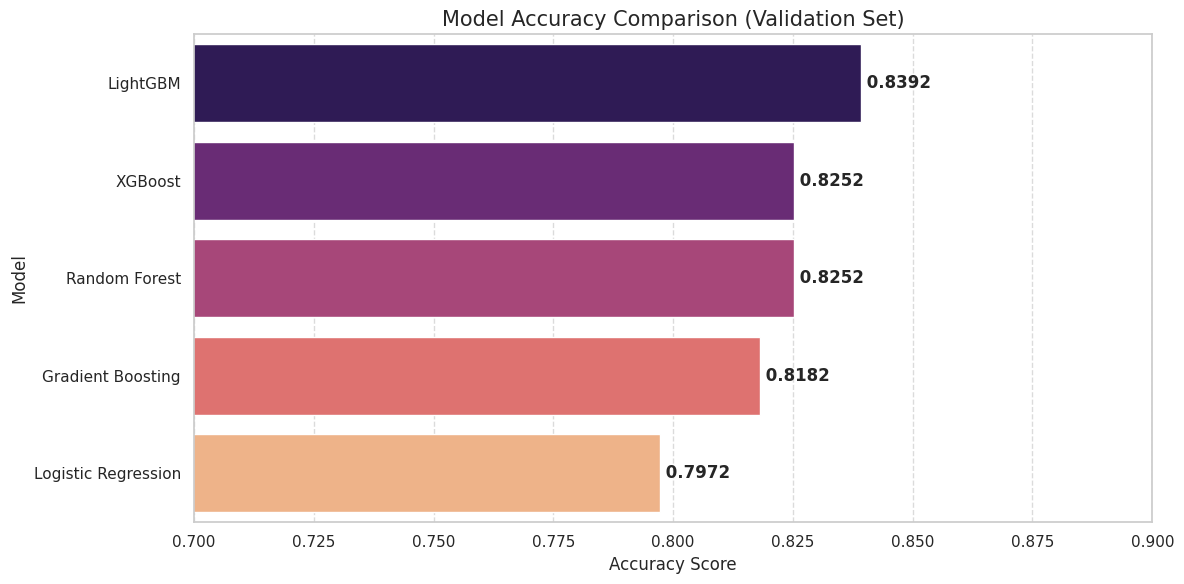

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)


plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='magma', hue='Model', legend=False)


plt.title('Model Accuracy Comparison (Validation Set)', fontsize=15)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.7, 0.9) 


for index, value in enumerate(results_df['Accuracy']):
    plt.text(value, index, f' {value:.4f}', va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:** Comparing validation accuracies, LightGBM is the top-performing model (83.92%), followed by Random Forest and XGBoost (82.52%), Gradient Boosting (81.82%), and Logistic Regression (79.72%).

In [23]:
# 1. Prepare the test features 
X_test_final = test_df.drop(columns=['PassengerId', 'PassengerName', 'Outcome'], errors='ignore')


X_test_final[ord_cols] = ord_encoder.transform(X_test_final[ord_cols].astype(str))


from sklearn.preprocessing import LabelEncoder
le_temp = LabelEncoder()
for col in ['Gender', 'BoardingPort', 'Title']:
    if col in X_test_final.columns:
        
        X_test_final[col] = le_temp.fit_transform(X_test_final[col].astype(str))


test_preds = lgbm_model.predict(X_test_final)


submission_df = pd.DataFrame({
    'PassengerName': test_df['PassengerName'],
    'Outcome': test_preds
})

submission_df.to_csv('submission.csv', index=False)
print("saved to submision")
display(submission_df.head())

saved to submision


,PassengerName,Outcome
0,"Moubarek, Master. Halim Gonios (""William George"")",1
1,"Kvillner, Mr. Johan Henrik Johannesson",0
2,"Alhomaki, Mr. Ilmari Rudolf",0
3,"Harper, Miss. Annie Jessie ""Nina""",1
4,"Nicola-Yarred, Miss. Jamila",1


**Insight:** We apply the same encoding transformations to the final test features, generate predictions using our top-performing LightGBM model, and save the results as `submission.csv` containing the passenger names and predicted survival outcomes.